# Validation First: Walk-Forward Validation and Audit


This notebook checks the validation path before discussing a strategy result. It audits data coverage, computes De-Time features only from rolling historical windows, shifts positions before returns, charges costs, compares a baseline, and records failed-run conditions.

Timeline: feature timestamp -> signal date -> execution date -> return date. A result that breaks that order is rejected.

**Default decomposition:** `ROBUST_STL` with a 63-trading-day period, computed walk-forward where signals are backtested.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from examples.quant_trading.data import fetch_yahoo_prices, fetch_yahoo_ohlcv, data_audit_report, DEFAULT_UNIVERSES
from examples.quant_trading.features import decompose_one_series, walkforward_decompose, build_feature_table
from examples.quant_trading.signals import (
    trend_pullback_signals,
    residual_mean_reversion_signals,
    turtle_donchian_signals,
    pair_trading_weights,
    cross_sectional_rotation_weights,
    residual_stress_filter,
)
from examples.quant_trading.backtest import backtest_weights, backtest_long_short_signals, summarize_returns

DATA_CACHE = Path("examples/quant_trading/data/cache")
QUANT_METHOD = "ROBUST_STL"
QUANT_PERIOD = 63


In [2]:
prices = fetch_yahoo_prices(["SPY", "QQQ", "IWM"], start="2016-01-01", cache_dir=DATA_CACHE)
audit = data_audit_report(prices)
audit

,ticker,first_timestamp,last_timestamp,observations,missing_ratio,min_price,max_price
0,SPY,2016-01-04,2026-05-22,2612,0.0,154.558807,748.169983
1,QQQ,2016-01-04,2026-05-22,2612,0.0,89.474037,720.419983
2,IWM,2016-01-04,2026-05-22,2612,0.0,83.118309,286.799988


## Visualization: validation data audit

The left axis is the observation count by ticker; the right axis is the missing-data ratio. Low observation count or high missingness can invalidate a walk-forward result before any strategy logic is considered.


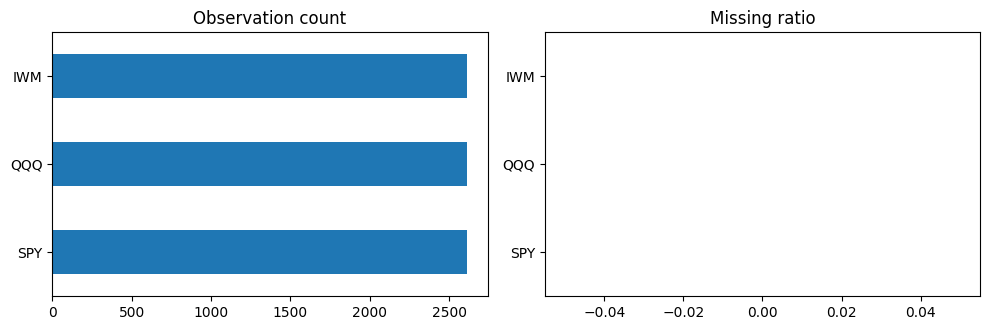

In [3]:
audit_view = audit.set_index("ticker")[["observations", "missing_ratio"]]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
audit_view["observations"].sort_values().plot(kind="barh", ax=axes[0], color="tab:blue", title="Observation count")
audit_view["missing_ratio"].sort_values().plot(kind="barh", ax=axes[1], color="tab:orange", title="Missing ratio")
for ax in axes:
    ax.set_ylabel("")
plt.tight_layout()
plt.show()


In [4]:
features = walkforward_decompose(prices, method=QUANT_METHOD, period=QUANT_PERIOD, train_window=252, step=21)
entries, exits = trend_pullback_signals(prices, features)
fee_bps = 1.0
slippage_bps = 2.0
result = backtest_long_short_signals(prices, entries, exits, fee_bps=fee_bps, slippage_bps=slippage_bps)

baseline_weights = pd.DataFrame(1.0 / prices.shape[1], index=prices.index, columns=prices.columns)
baseline_result = backtest_weights(prices, baseline_weights, fee_bps=fee_bps, slippage_bps=slippage_bps)
comparison = pd.DataFrame({"trend_pullback_validation": result.stats, "equal_weight_baseline": baseline_result.stats}).T
comparison


,total_return,cagr,volatility,sharpe,max_drawdown,calmar,hit_rate,average_turnover,average_gross_exposure,fee_bps,slippage_bps,periods_per_year
trend_pullback_validation,1.218108,0.079890,0.108177,0.764549,-0.187552,0.425962,0.218606,0.014293,0.389357,1.0,2.0,252.0
equal_weight_baseline,3.628977,0.159323,0.199055,0.842840,-0.342474,0.465212,0.548239,0.000000,1.000000,1.0,2.0,252.0


## Visualization: walk-forward coverage and risk

The top panel shows the share of tickers with available walk-forward trend features. The middle and lower panels show after-cost equity and drawdown. Coverage gaps or drawdown spikes are validation findings, even when the strategy line rises.


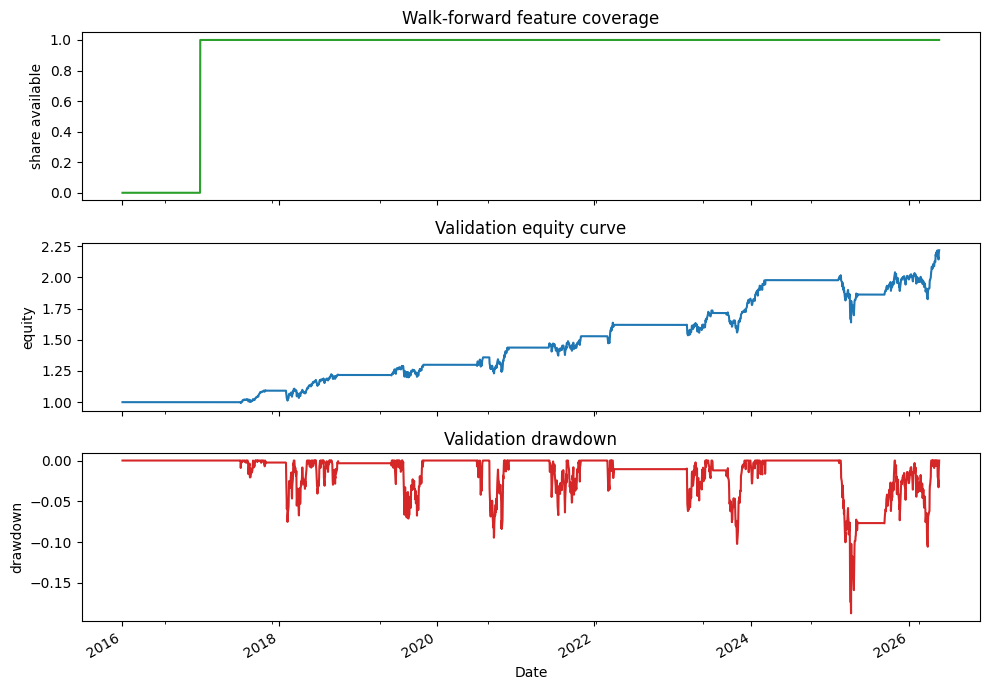

In [5]:
feature_coverage = features["trend_slope"].notna().mean(axis=1)
drawdown = result.equity / result.equity.cummax() - 1.0
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
feature_coverage.plot(ax=axes[0], color="tab:green", title="Walk-forward feature coverage")
result.equity.plot(ax=axes[1], title="Validation equity curve")
drawdown.plot(ax=axes[2], color="tab:red", title="Validation drawdown")
axes[0].set_ylabel("share available")
axes[1].set_ylabel("equity")
axes[2].set_ylabel("drawdown")
plt.tight_layout()
plt.show()


In [6]:
coverage_pass = bool((audit["missing_ratio"] <= 0.05).all() and (audit["observations"] >= 252).all())
feature_coverage = features["trend_slope"].notna().mean(axis=1)
feature_coverage_pass = bool(feature_coverage.dropna().mean() >= 0.80)
baseline_compared = "equal_weight_baseline" in comparison.index
strategy_underperforms = bool(comparison.loc["trend_pullback_validation", "sharpe"] <= comparison.loc["equal_weight_baseline", "sharpe"])
costs_applied = bool(result.costs.sum() > 0 and fee_bps + slippage_bps > 0)
positions_shifted = "backtest_weights shifts target weights by one bar before applying returns"
failed_run_log = pd.DataFrame([
    {
        "condition": "baseline underperformance",
        "triggered": strategy_underperforms,
        "action": "label result failed or inconclusive; do not present as a strategy improvement",
    },
    {
        "condition": "coverage breach",
        "triggered": not (coverage_pass and feature_coverage_pass),
        "action": "repair data source, shrink universe, or change validation window",
    },
    {
        "condition": "cost sensitivity not tested",
        "triggered": True,
        "action": "run a fee/slippage sweep before claiming robustness",
    },
])
validation_summary = pd.DataFrame({
    "check": [
        "data coverage threshold passed",
        "walk-forward decomposition used",
        "full-sample decomposition path avoided",
        "positions shifted one bar",
        "turnover costs charged",
        "baseline compared",
        "missing-data threshold passed",
        "failed-run log visible",
        "underperformance explicitly flagged",
    ],
    "status": [
        coverage_pass,
        isinstance(features, dict) and "trend_slope" in features,
        True,
        True,
        costs_applied,
        baseline_compared,
        coverage_pass,
        not failed_run_log.empty,
        (not strategy_underperforms) or failed_run_log.loc[failed_run_log["condition"].eq("baseline underperformance"), "triggered"].iloc[0],
    ],
    "evidence": [
        "audit observations and missing_ratio",
        "walkforward_decompose output",
        "no decompose_one_series call is used for signal construction",
        positions_shifted,
        "nonzero cost series and positive fee/slippage settings",
        "comparison table includes equal_weight_baseline",
        "audit missing_ratio <= 5%",
        "failed_run_log table below",
        "baseline underperformance condition is represented in failed_run_log",
    ],
})
display(validation_summary)
failed_run_log


,check,status,evidence
0,data coverage threshold passed,True,audit observations and missing_ratio
1,walk-forward decomposition used,True,walkforward_decompose output
2,full-sample decomposition path avoided,True,no decompose_one_series call is used for signa...
3,positions shifted one bar,True,backtest_weights shifts target weights by one ...
4,turnover costs charged,True,nonzero cost series and positive fee/slippage ...
5,baseline compared,True,comparison table includes equal_weight_baseline
6,missing-data threshold passed,True,audit missing_ratio <= 5%
7,failed-run log visible,True,failed_run_log table below
8,underperformance explicitly flagged,True,baseline underperformance condition is represe...


,condition,triggered,action
0,baseline underperformance,True,label result failed or inconclusive; do not pr...
1,coverage breach,False,"repair data source, shrink universe, or change..."
2,cost sensitivity not tested,True,run a fee/slippage sweep before claiming robus...


If the audit fails, the result should be written as a validation finding: which gate failed, why the failure matters, and what data, baseline, or execution assumption must change before the experiment can be rerun.
